In [1]:
# Enhanced Movie Success Prediction Analysis

## Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, StackingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

In [2]:

# Set plotting styles
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

In [3]:

# Try importing optional libraries
try:
    import xgboost as xgb
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("XGBoost not available. Skipping XGBoost models.")

try:
    import lightgbm as lgb
    from lightgbm import LGBMRegressor
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False
    print("LightGBM not available. Skipping LightGBM models.")

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print("SHAP not available. Skipping SHAP analyses.")

In [4]:

## Data Loading
print("Loading data...")
# Replace this with your actual file path
file_path = "output/cleaned_movie_released_nonzero.csv"
df = pd.read_csv(file_path)
print(f"Loaded dataset with {df.shape[0]} rows and {df.shape[1]} columns")

Loading data...
Loaded dataset with 10458 rows and 52 columns


In [5]:

## Data Exploration
print("\n--- Basic Dataset Information ---")
print(df.info())

print("\n--- Summary Statistics ---")
print(df.describe())

# Check missing values
missing_values = df.isnull().sum()
print("\n--- Missing Values ---")
print(missing_values[missing_values > 0])


--- Basic Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10458 entries, 0 to 10457
Data columns (total 52 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   title                                          10458 non-null  object 
 1   vote_average                                   10458 non-null  float64
 2   vote_count                                     10458 non-null  int64  
 3   status                                         10458 non-null  object 
 4   release_date                                   10338 non-null  object 
 5   revenue                                        10458 non-null  int64  
 6   runtime                                        10458 non-null  int64  
 7   adult                                          10458 non-null  int64  
 8   budget                                         10458 non-null  int64  
 9   original_langua

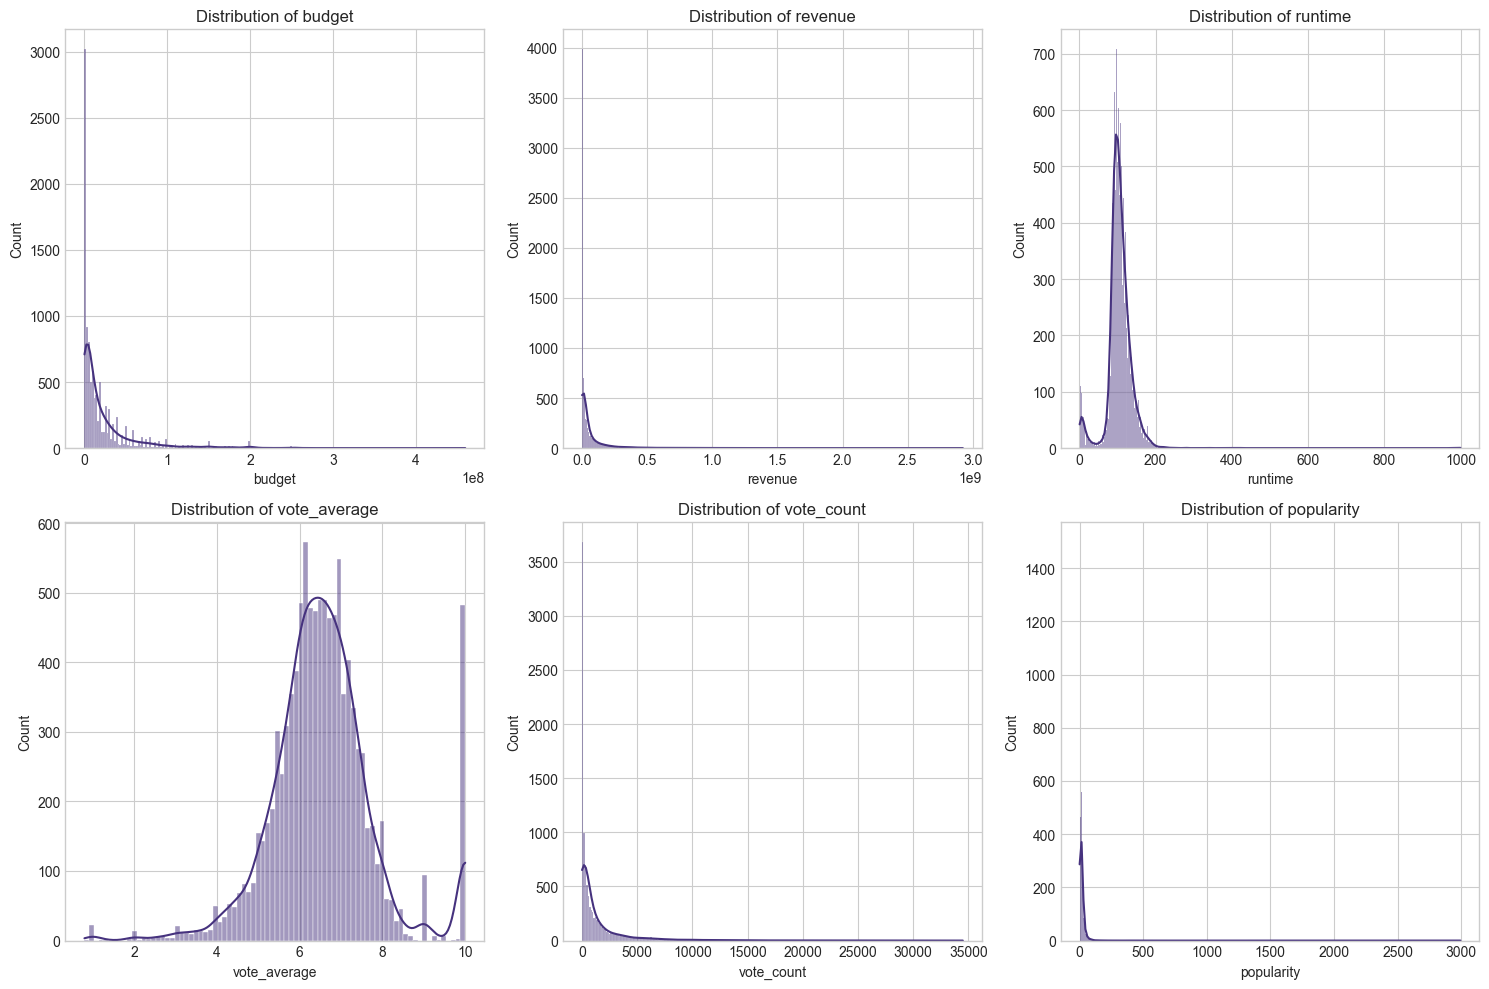

In [6]:

# Examine distribution of key variables
numerical_cols = ['budget', 'revenue', 'runtime', 'vote_average', 'vote_count', 'popularity']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i+1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
# plt.savefig('numerical_distributions.png')
# plt.close()
plt.show()

Thanks for the visual! Based on these distributions, here's a quick assessment of whether you should apply a **log transform (`np.log1p`)**, **standardization (`StandardScaler`)**, or both:

---

### 🔍 Breakdown by Feature:

| Feature        | Shape from Plot         | Suggestion                                      |
|----------------|--------------------------|--------------------------------------------------|
| **`budget`**      | **Heavily right-skewed**   | ✅ `np.log1p` first, then `StandardScaler`        |
| **`revenue`**     | **Extremely skewed**       | ✅ `np.log1p`, then scale                         |
| **`runtime`**     | Fairly normal, slight skew | 🔸 Maybe just `StandardScaler` (log optional)     |
| **`vote_average`**| Roughly normal             | ❌ No transform needed (maybe just scale)         |
| **`vote_count`**  | **Heavily right-skewed**   | ✅ `np.log1p`, then scale                         |
| **`popularity`**  | **Heavily skewed**         | ✅ `np.log1p`, then scale                         |

---

### ✅ What to Do

For `budget`, `revenue`, `vote_count`, and `popularity`, this approach works well:

```python
from sklearn.preprocessing import StandardScaler
import numpy as np

cols_to_log = ['budget', 'revenue', 'vote_count', 'popularity']
df_log_scaled = df.copy()

# Apply log1p
for col in cols_to_log:
    df_log_scaled[col] = np.log1p(df_log_scaled[col])

# Then standardize
scaler = StandardScaler()
df_log_scaled[cols_to_log] = scaler.fit_transform(df_log_scaled[cols_to_log])
```

For `runtime`, standardization is usually enough.  
For `vote_average`, you likely don't need anything (though you can standardize it for regression or clustering).

---

Let me know if you want to plot the **post-transform distributions** to double-check how they look — always a good sanity check.

In [7]:
df.describe()

,vote_average,vote_count,revenue,runtime,adult,budget,popularity,release_year,release_quarter,release_month,...,production_countries_United States of America,production_countries_France,production_countries_Japan,production_countries_Germany,production_countries_United Kingdom,spoken_languages_English,spoken_languages_French,spoken_languages_Spanish,spoken_languages_Japanese,spoken_languages_German
count,10458.000000,10458.000000,1.045800e+04,10458.000000,10458.000000,1.045800e+04,10458.000000,10458.000000,10458.000000,10458.000000,...,10458.000000,10458.000000,10458.000000,10458.000000,10458.000000,10458.000000,10458.000000,10458.000000,10458.000000,10458.000000
mean,6.551855,1462.347581,6.436654e+07,105.004877,0.002104,2.272996e+07,18.563980,1978.836680,2.583190,6.811054,...,0.678237,0.075731,0.024766,0.050966,0.112928,0.777395,0.088162,0.080704,0.028304,0.047810
std,1.263635,2929.448101,1.547616e+08,36.116910,0.045820,3.753601e+07,60.390318,214.011497,1.140596,3.488127,...,0.467175,0.264581,0.155418,0.219938,0.316520,0.416015,0.283544,0.272393,0.165847,0.213375
min,0.800000,1.000000,-1.200000e+01,1.000000,0.000000,1.000000e+00,0.600000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.879250,47.000000,1.400000e+06,92.000000,0.000000,1.600000e+06,5.391000,1995.000000,2.000000,4.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,6.500000,351.000000,1.160000e+07,104.000000,0.000000,8.700000e+06,12.612000,2007.000000,3.000000,7.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,7.145750,1459.000000,5.500000e+07,120.000000,0.000000,2.600000e+07,20.063500,2015.000000,4.000000,10.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,10.000000,34495.000000,2.923706e+09,999.000000,1.000000,4.600000e+08,2994.357000,2025.000000,4.000000,12.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


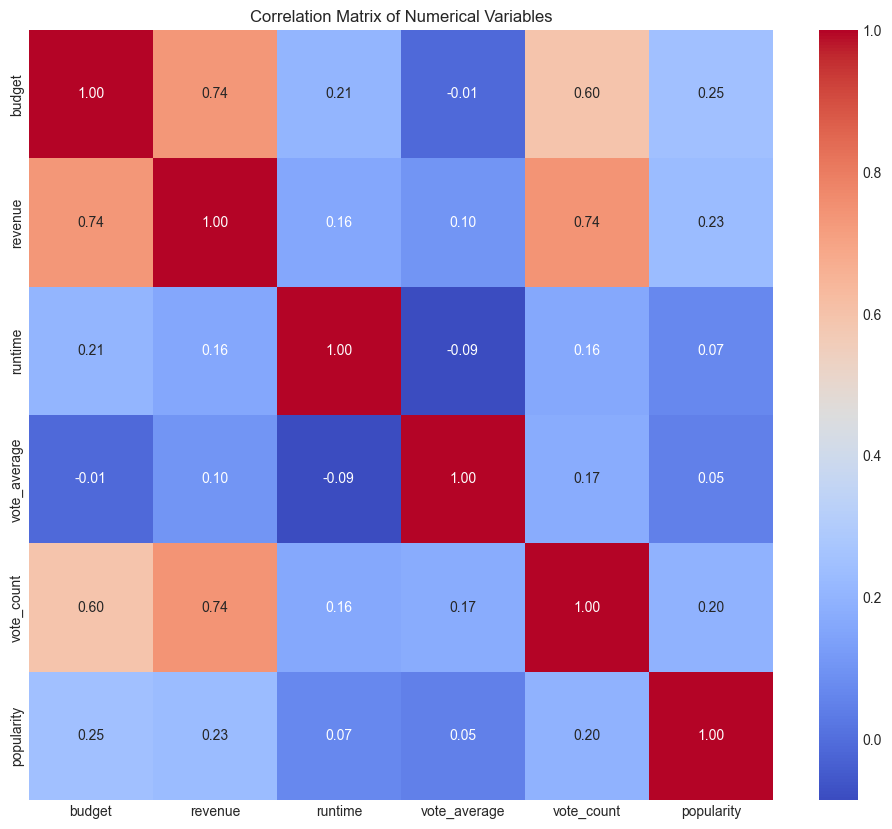

In [8]:
# Examine correlations
plt.figure(figsize=(12, 10))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Variables')
# plt.savefig('correlation_matrix.png')
# plt.close()
plt.show()

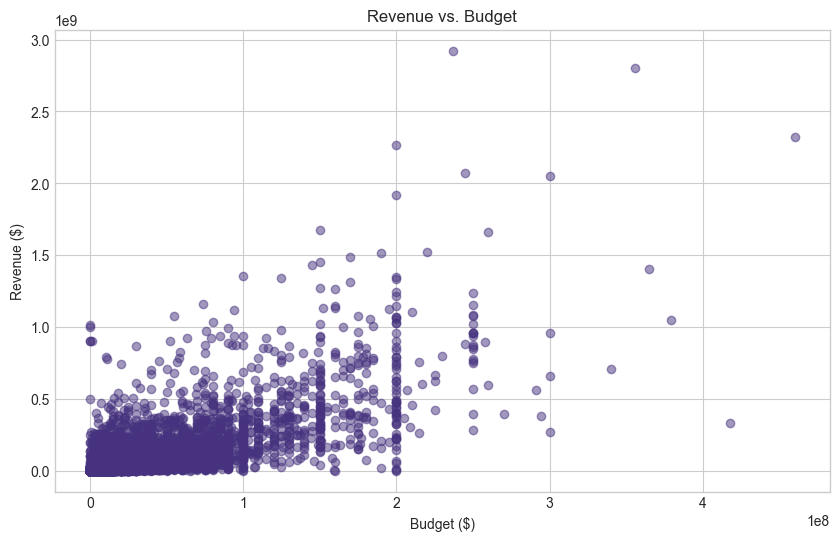

In [9]:
# Plot revenue vs budget
plt.figure(figsize=(10, 6))
plt.scatter(df['budget'], df['revenue'], alpha=0.5)
plt.title('Revenue vs. Budget')
plt.xlabel('Budget ($)')
plt.ylabel('Revenue ($)')
# plt.savefig('revenue_vs_budget.png')
# plt.close()
plt.show()

In [10]:
## Feature Engineering

print("\n--- Feature Engineering ---")

# Create a copy for feature engineering
df_engineered = df.copy()



--- Feature Engineering ---


In [11]:
# 1. Log transformations for skewed variables
for col in ['budget', 'revenue', 'vote_count', 'popularity']:
    df_engineered[f'log_{col}'] = np.log1p(df_engineered[col])


In [12]:
# 2. Calculate ROI
df_engineered['roi'] = (df_engineered['revenue'] - df_engineered['budget']) / df_engineered['budget']


In [13]:
# 3. Budget per runtime (cost per minute)
df_engineered['budget_per_minute'] = df_engineered['budget'] / df_engineered['runtime'].replace(0, 1)


In [14]:
# 4. Convert release_date to datetime
df_engineered['release_date'] = pd.to_datetime(df_engineered['release_date'])


In [15]:
# 5. More temporal features
# df_engineered['release_day'] = df_engineered['release_date'].dt.day
df_engineered['is_holiday_season'] = df_engineered['release_month'].isin([11, 12, 5, 6, 7]).astype(int)
df_engineered['is_weekend_release'] = df_engineered['release_date'].dt.dayofweek >= 5
# df_engineered['days_since_2000'] = (df_engineered['release_date'] - pd.Timestamp('2000-01-01')).dt.days


In [16]:
# 6. Competition features
release_counts = df_engineered.groupby(['release_year', 'release_month']).size()
df_engineered['release_competition'] = df_engineered.apply(
    lambda x: release_counts.get((x['release_year'], x['release_month']), 0), 
    axis=1
)


In [17]:
# 7. Genre count and combinations
genre_cols = [col for col in df_engineered.columns if col.startswith('genre_')]
df_engineered['genre_count'] = df_engineered[genre_cols].sum(axis=1)


In [18]:
# 8. Interaction terms
df_engineered['budget_x_competition'] = df_engineered['log_budget'] * df_engineered['release_competition']
df_engineered['budget_x_holiday'] = df_engineered['log_budget'] * df_engineered['is_holiday_season']


In [19]:
# Print info about new features
print(f"Original dataset had {df.shape[1]} columns")
print(f"Engineered dataset has {df_engineered.shape[1]} columns")
print(f"Added {df_engineered.shape[1] - df.shape[1]} new features")


Original dataset had 52 columns
Engineered dataset has 64 columns
Added 12 new features


In [20]:
## Preparing Data for Modeling

# Define target variables
y_revenue = df_engineered['revenue']
y_log_revenue = df_engineered['log_revenue']
y_popularity = df_engineered['popularity']
y_vote_count = df_engineered['vote_count']
y_vote_average = df_engineered['vote_average']
y_roi = df_engineered['roi']


In [21]:
# Define features to exclude (target variables and raw features replaced by engineered ones)
exclude_cols = [
    'title', 'original_title', 'overview', 'keywords', 'status', 'release_date', 
    'revenue', 'log_revenue', 'popularity', 'log_popularity', 'vote_count', 
    'log_vote_count', 'vote_average', 'roi', '', 'adult', 'original_language',
    'release_season'  # Since we have more detailed seasonal features
]


In [22]:
# Select features
X_cols = [col for col in df_engineered.columns if col not in exclude_cols]
X = df_engineered[X_cols]

print(f"\nSelected {len(X_cols)} features for modeling")



Selected 47 features for modeling


In [23]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10458 entries, 0 to 10457
Data columns (total 47 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   runtime                                        10458 non-null  int64  
 1   budget                                         10458 non-null  int64  
 2   release_year                                   10458 non-null  int64  
 3   release_quarter                                10458 non-null  int64  
 4   release_month                                  10458 non-null  int64  
 5   genre_Action                                   10458 non-null  int64  
 6   genre_Adventure                                10458 non-null  int64  
 7   genre_Animation                                10458 non-null  int64  
 8   genre_Comedy                                   10458 non-null  int64  
 9   genre_Crime                                    104

In [24]:
# Create train-test splits
test_size = 0.2
random_state = 42

X_train_revenue, X_test_revenue, y_train_revenue, y_test_revenue = train_test_split(
    X, y_revenue, test_size=test_size, random_state=random_state
)

In [25]:

X_train_log_revenue, X_test_log_revenue, y_train_log_revenue, y_test_log_revenue = train_test_split(
    X, y_log_revenue, test_size=test_size, random_state=random_state
)
nan_index = y_train_log_revenue[y_train_log_revenue.isna()].index

X_train_log_revenue = X_train_log_revenue.drop(index=nan_index)
y_train_log_revenue = y_train_log_revenue.drop(index=nan_index)



In [26]:
X_train_popularity, X_test_popularity, y_train_popularity, y_test_popularity = train_test_split(
    X, y_popularity, test_size=test_size, random_state=random_state
)


In [27]:
X_train_vote_count, X_test_vote_count, y_train_vote_count, y_test_vote_count = train_test_split(
    X, y_vote_count, test_size=test_size, random_state=random_state
)


In [28]:
X_train_vote_average, X_test_vote_average, y_train_vote_average, y_test_vote_average = train_test_split(
    X, y_vote_average, test_size=test_size, random_state=random_state
)


In [29]:
X_train_roi, X_test_roi, y_train_roi, y_test_roi = train_test_split(
    X, y_roi, test_size=test_size, random_state=random_state
)


In [30]:
## Model Development

print("\n--- Model Development ---")

# Define a dictionary of models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.001),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=4,
        min_samples_split=4,
        min_samples_leaf=1,
        random_state=random_state
    ),
    'Random Forest': RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        random_state=random_state,
        n_jobs=-1
    )
}



--- Model Development ---


In [40]:
# Add XGBoost if available
if HAS_XGB:
    models['XGBoost'] = XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=4,
        random_state=random_state,
        n_jobs=-1
    )

# Add LightGBM if available
# if HAS_LGBM:
#     models['LightGBM'] = LGBMRegressor(
#         n_estimators=100,
#         learning_rate=0.1,
#         max_depth=4,
#         random_state=random_state,
#         n_jobs=-1
#     )
if HAS_LGBM:
    models['LightGBM'] = LGBMRegressor(
        n_estimators=500,             # More trees to learn subtle patterns
        learning_rate=0.05,           # Lower LR for better generalization
        max_depth=-1,                 # Let LightGBM decide; avoids underfitting
        num_leaves=31,                # Default good starting point
        min_child_samples=20,         # Controls overfitting
        min_gain_to_split=0.0,        # Remove gain threshold to allow all splits
        reg_alpha=0.0,                # Turn off L1 regularization for now
        reg_lambda=0.0,               # Turn off L2 regularization for now
        subsample=0.8,                # Randomly sample rows per tree
        colsample_bytree=0.8,         # Randomly sample features per tree
        random_state=random_state,
        n_jobs=-1,
        verbose=-1
    )


In [41]:
# Function to train and evaluate models
def train_and_evaluate_models(X_train, X_test, y_train, y_test, models, target_name):
    results = {}
    
    print(f"\nTraining models for predicting {target_name}...")
    
    for name, model in models.items():
        # Train the model
        model.fit(X_train, y_train)
        
        # Make predictions
        y_pred = model.predict(X_test)
        
        # Calculate metrics
        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, y_pred)
        
        # Store results
        results[name] = {
            'MAE': mae,
            'MSE': mse,
            'RMSE': rmse,
            'R²': r2,
            'Predictions': y_pred,
            'Model': model
        }
        
        print(f"{name} - MAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.4f}")
    
    return results


In [42]:
# Train models for each target
revenue_results = train_and_evaluate_models(
    X_train_revenue, X_test_revenue, y_train_revenue, y_test_revenue, models, 'Revenue'
)


Training models for predicting Revenue...
Linear Regression - MAE: 48573952.59, RMSE: 110634526.90, R²: 0.5228
Ridge - MAE: 48565453.25, RMSE: 110634077.44, R²: 0.5228
Lasso - MAE: 48573952.58, RMSE: 110634526.90, R²: 0.5228
Gradient Boosting - MAE: 45986292.84, RMSE: 114920776.73, R²: 0.4851
Random Forest - MAE: 46224252.46, RMSE: 113368126.93, R²: 0.4989
XGBoost - MAE: 45948216.00, RMSE: 114003074.35, R²: 0.4933
LightGBM - MAE: 47202018.73, RMSE: 115618240.94, R²: 0.4788


In [43]:

log_revenue_results = train_and_evaluate_models(
    X_train_log_revenue, X_test_log_revenue, y_train_log_revenue, y_test_log_revenue, models, 'Log Revenue'
)


Training models for predicting Log Revenue...
Linear Regression - MAE: 1.34, RMSE: 2.00, R²: 0.7278
Ridge - MAE: 1.34, RMSE: 2.00, R²: 0.7278
Lasso - MAE: 1.34, RMSE: 2.00, R²: 0.7276
Gradient Boosting - MAE: 1.30, RMSE: 1.96, R²: 0.7375
Random Forest - MAE: 1.31, RMSE: 1.96, R²: 0.7373
XGBoost - MAE: 1.30, RMSE: 1.94, R²: 0.7426
LightGBM - MAE: 1.30, RMSE: 1.95, R²: 0.7411


In [44]:

popularity_results = train_and_evaluate_models(
    X_train_popularity, X_test_popularity, y_train_popularity, y_test_popularity, models, 'Popularity'
)



Training models for predicting Popularity...
Linear Regression - MAE: 10.94, RMSE: 21.72, R²: 0.2039
Ridge - MAE: 10.93, RMSE: 21.72, R²: 0.2043
Lasso - MAE: 10.93, RMSE: 21.72, R²: 0.2043
Gradient Boosting - MAE: 8.98, RMSE: 32.82, R²: -0.8173
Random Forest - MAE: 8.24, RMSE: 24.42, R²: -0.0058
XGBoost - MAE: 9.10, RMSE: 36.88, R²: -1.2937
LightGBM - MAE: 9.36, RMSE: 26.24, R²: -0.1612


In [45]:
vote_count_results = train_and_evaluate_models(
    X_train_vote_count, X_test_vote_count, y_train_vote_count, y_test_vote_count, models, 'Vote Count'
)



Training models for predicting Vote Count...
Linear Regression - MAE: 1286.30, RMSE: 2463.24, R²: 0.3580
Ridge - MAE: 1286.02, RMSE: 2463.25, R²: 0.3580
Lasso - MAE: 1286.30, RMSE: 2463.24, R²: 0.3580
Gradient Boosting - MAE: 1171.82, RMSE: 2329.43, R²: 0.4259
Random Forest - MAE: 1176.16, RMSE: 2361.68, R²: 0.4099
XGBoost - MAE: 1171.51, RMSE: 2317.32, R²: 0.4318
LightGBM - MAE: 1177.43, RMSE: 2311.23, R²: 0.4348


In [46]:
vote_average_results = train_and_evaluate_models(
    X_train_vote_average, X_test_vote_average, y_train_vote_average, y_test_vote_average, models, 'Vote Average'
)



Training models for predicting Vote Average...
Linear Regression - MAE: 0.80, RMSE: 1.12, R²: 0.2029
Ridge - MAE: 0.80, RMSE: 1.12, R²: 0.2029
Lasso - MAE: 0.80, RMSE: 1.12, R²: 0.2020
Gradient Boosting - MAE: 0.74, RMSE: 1.06, R²: 0.2895
Random Forest - MAE: 0.75, RMSE: 1.06, R²: 0.2841
XGBoost - MAE: 0.74, RMSE: 1.05, R²: 0.3011
LightGBM - MAE: 0.73, RMSE: 1.04, R²: 0.3121


In [47]:
roi_results = train_and_evaluate_models(
    X_train_roi, X_test_roi, y_train_roi, y_test_roi, models, 'ROI'
)



Training models for predicting ROI...
Linear Regression - MAE: 482977.18, RMSE: 1109379.48, R²: -59.8645
Ridge - MAE: 482637.19, RMSE: 1109170.61, R²: -59.8416
Lasso - MAE: 482977.17, RMSE: 1109379.47, R²: -59.8645
Gradient Boosting - MAE: 12706.16, RMSE: 177061.68, R²: -0.5504
Random Forest - MAE: 61299.96, RMSE: 1077893.32, R²: -56.4586
XGBoost - MAE: 21841.66, RMSE: 302191.53, R²: -3.5162
LightGBM - MAE: 241896.59, RMSE: 1877602.13, R²: -173.3456


In [49]:
## Model Evaluation and Visualization

print("\n--- Model Evaluation and Visualization ---")

# Function to plot actual vs predicted values
def plot_predictions(y_true, y_pred, title, filename):
    plt.figure(figsize=(10, 6))
    plt.scatter(y_true, y_pred, alpha=0.5)
    
    # Add perfect prediction line
    max_val = max(max(y_true), max(y_pred))
    min_val = min(min(y_true), min(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val], 'r--')
    
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(title)
    plt.tight_layout()
    # plt.savefig(filename)
    # plt.close()
    plt.show()


--- Model Evaluation and Visualization ---


In [51]:
# Function to plot residuals
def plot_residuals(y_true, y_pred, title, filename):
    residuals = y_true - y_pred
    
    plt.figure(figsize=(10, 6))
    plt.scatter(y_pred, residuals, alpha=0.5)
    plt.axhline(y=0, color='r', linestyle='--')
    
    plt.xlabel('Predicted Values')
    plt.ylabel('Residuals')
    plt.title(title)
    plt.tight_layout()
    # plt.savefig(filename)
    # plt.close()
    plt.show()

In [52]:
# Function to compare model performance
def compare_models(results_dict, metric, title, filename):
    model_names = list(results_dict.keys())
    metric_values = [results_dict[model][metric] for model in model_names]
    
    plt.figure(figsize=(12, 6))
    bars = plt.bar(model_names, metric_values)
    
    # Add value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height+0.001,
                 f'{height:.4f}', ha='center', va='bottom', rotation=0)
    
    plt.xlabel('Model')
    plt.ylabel(metric)
    plt.title(title)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    # plt.savefig(filename)
    # plt.close()
    plt.show()

In [53]:
# Select best model for revenue prediction (e.g., Gradient Boosting)
best_revenue_model_name = max(revenue_results, key=lambda x: revenue_results[x]['R²'])
best_revenue_model = revenue_results[best_revenue_model_name]['Model']
best_revenue_preds = revenue_results[best_revenue_model_name]['Predictions']


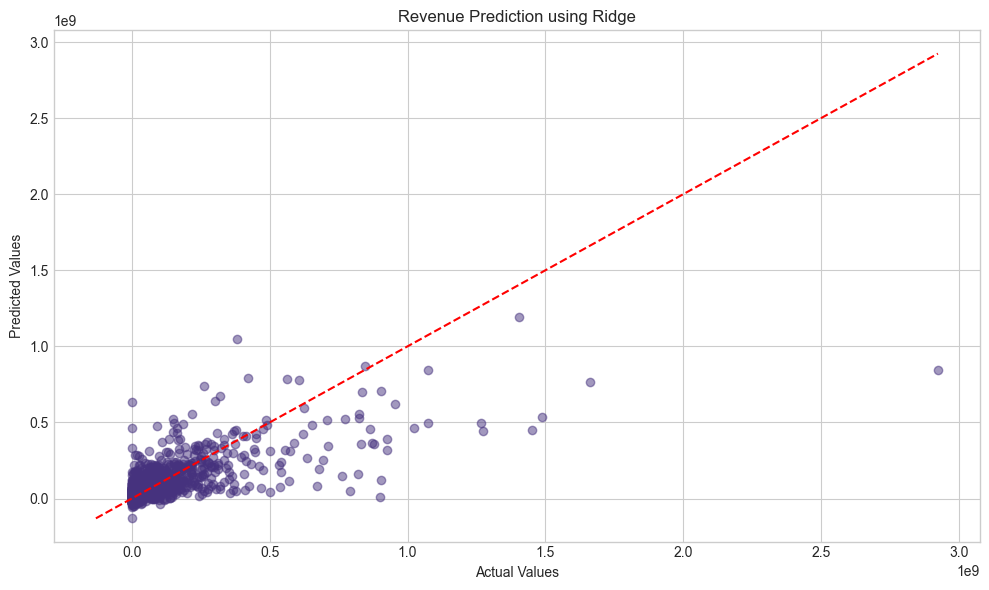

In [54]:
# Visualize revenue predictions
plot_predictions(
    y_test_revenue, 
    best_revenue_preds, 
    f'Revenue Prediction using {best_revenue_model_name}', 
    'revenue_predictions.png'
)


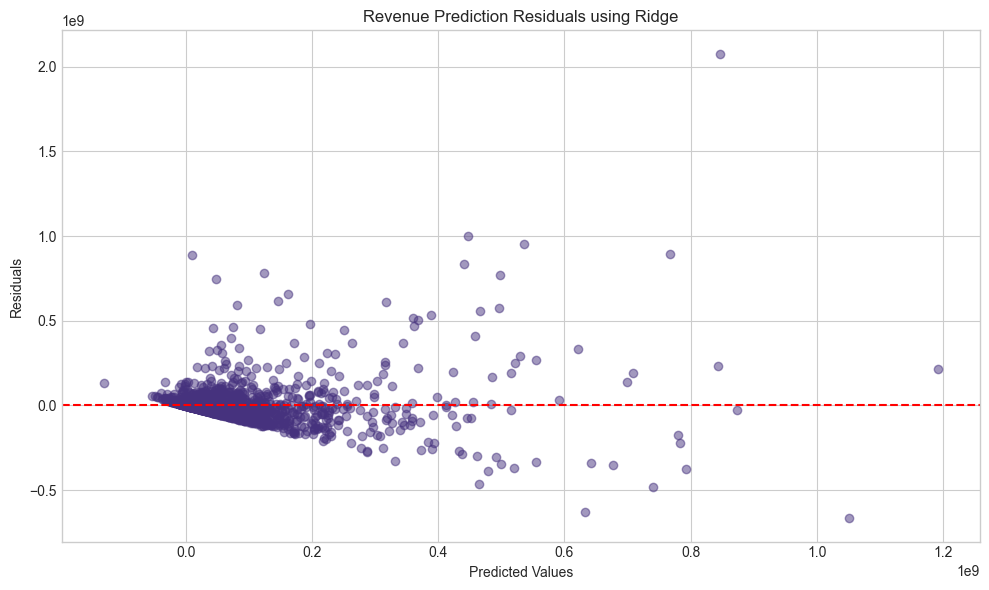

In [55]:
plot_residuals(
    y_test_revenue, 
    best_revenue_preds, 
    f'Revenue Prediction Residuals using {best_revenue_model_name}', 
    'revenue_residuals.png'
)


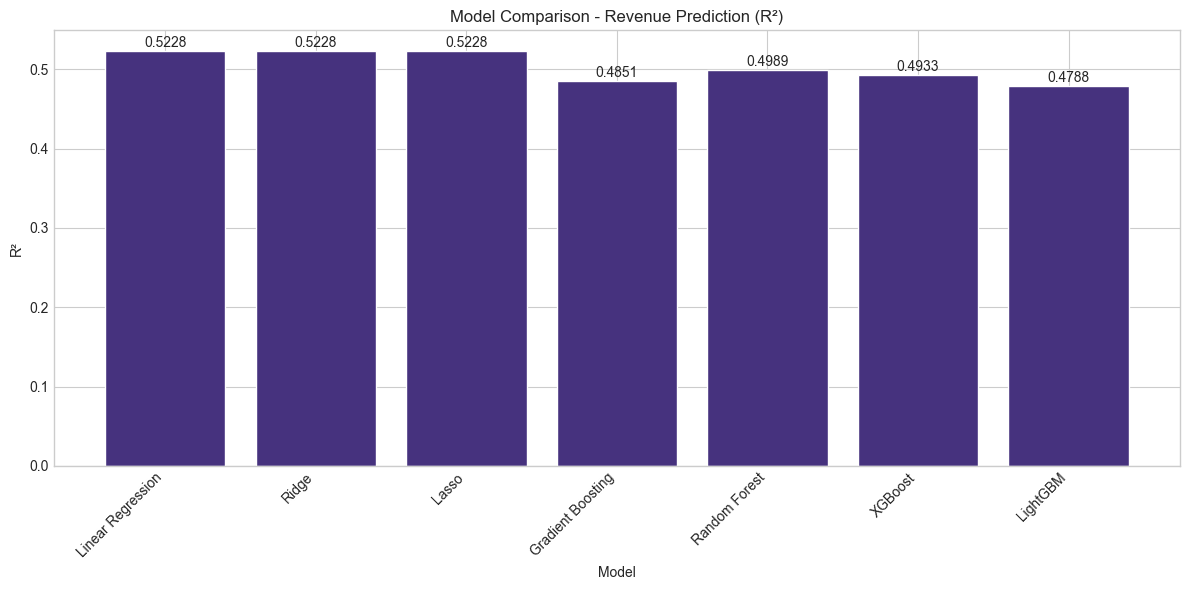

In [56]:
# Compare model performance for revenue
compare_models(
    revenue_results, 
    'R²', 
    'Model Comparison - Revenue Prediction (R²)', 
    'revenue_model_comparison_r2.png'
)


In [57]:
# Select best model for ROI prediction
best_roi_model_name = max(roi_results, key=lambda x: roi_results[x]['R²'])
best_roi_model = roi_results[best_roi_model_name]['Model']
best_roi_preds = roi_results[best_roi_model_name]['Predictions']


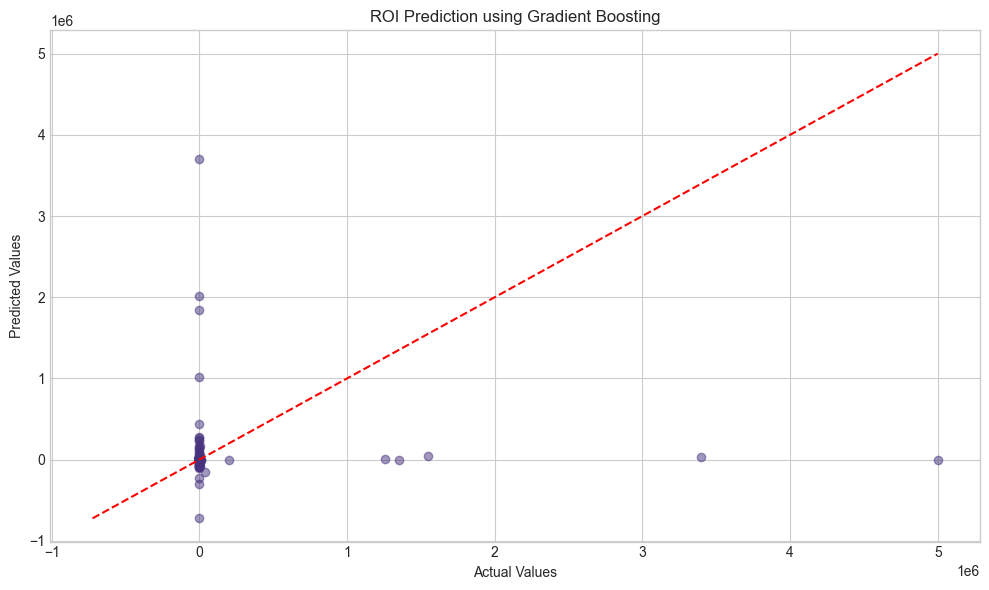

In [58]:
# Visualize ROI predictions
plot_predictions(
    y_test_roi, 
    best_roi_preds, 
    f'ROI Prediction using {best_roi_model_name}', 
    'roi_predictions.png'
)


In [59]:
## Feature Importance Analysis

print("\n--- Feature Importance Analysis ---")

# Function to plot feature importances
def plot_feature_importance(model, X_columns, title, filename, top_n=15):
    # Check if model has feature_importances_ attribute
    if not hasattr(model, 'feature_importances_'):
        print(f"Model doesn't have feature importances: {title}")
        return
    
    # Get feature importances
    importances = model.feature_importances_
    
    # Create a Series with feature names
    importance_df = pd.DataFrame({
        'Feature': X_columns,
        'Importance': importances
    }).sort_values('Importance', ascending=False).head(top_n)
    
    plt.figure(figsize=(12, 8))
    plt.barh(importance_df['Feature'], importance_df['Importance'])
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.title(title)
    plt.tight_layout()
    plt.savefig(filename)
    plt.close()
    
    return importance_df



--- Feature Importance Analysis ---


In [61]:
# import shap
# import matplotlib.pyplot as plt
# 
# # SHAP values for better feature importance understanding
# explainer = shap.TreeExplainer(gbr_revenue)
# shap_values = explainer.shap_values(X_test_revenue)
# 
# # SHAP summary plot (no need for plt.figure here)
# shap.summary_plot(shap_values, X_test_revenue, plot_type="bar")
# 
# # SHAP dependence plot (this one can use plt.figure)
# plt.figure(figsize=(12, 8))
# shap.dependence_plot("budget", shap_values, X_test_revenue)
# 
# # Analyze feature importance by genre
# def feature_importance_by_genre(model, X, genre_col):
#     genre_mask = X[genre_col] == 1
#     X_genre = X[genre_mask]
#     
#     # Get feature importances for just this genre's movies
#     if len(X_genre) > 10:  # Only analyze if enough samples
#         importances = pd.Series(model.feature_importances_, index=X.columns)
#         importances = importances.sort_values(ascending=False)
#         
#         # Plot top 10 features
#         plt.figure(figsize=(10, 6))
#         importances[:10].plot(kind='bar')
#         plt.title(f'Feature Importance for {genre_col.replace("genre_", "")}')
#         plt.tight_layout()
#         plt.show()
#         
#         return importances
#     return None
# 
# # Example usage for a specific genre
# feature_importance_by_genre(gbr_revenue, X, 'genre_Action')

In [62]:
# Analyze feature importance for ROI
roi_importance = plot_feature_importance(
    best_roi_model, 
    X.columns, 
    f'Top Features for ROI Prediction ({best_roi_model_name})', 
    'roi_feature_importance.png'
)

print("\nTop features for ROI prediction:")
print(roi_importance.head(10))



Top features for ROI prediction:
                     Feature  Importance
40         budget_per_minute    0.273484
9                genre_Crime    0.195941
39                log_budget    0.154532
1                     budget    0.143982
45      budget_x_competition    0.117386
21            genre_Thriller    0.049086
44               genre_count    0.024876
5               genre_Action    0.018521
34  spoken_languages_English    0.006076
4              release_month    0.005456


In [63]:
## Genre Analysis

print("\n--- Genre Analysis ---")

# Get list of genre columns
genre_columns = [col for col in df.columns if col.startswith('genre_')]

# Calculate average metrics by genre
genre_metrics = pd.DataFrame()

for genre_col in genre_columns:
    genre_name = genre_col.replace('genre_', '')
    movies_in_genre = df[df[genre_col] == 1]
    
    if len(movies_in_genre) > 0:
        genre_metrics.loc[genre_name, 'Count'] = len(movies_in_genre)
        genre_metrics.loc[genre_name, 'Avg Budget'] = movies_in_genre['budget'].mean()
        genre_metrics.loc[genre_name, 'Avg Revenue'] = movies_in_genre['revenue'].mean()
        genre_metrics.loc[genre_name, 'Avg ROI'] = (movies_in_genre['revenue'] - movies_in_genre['budget']).sum() / movies_in_genre['budget'].sum()
        genre_metrics.loc[genre_name, 'Avg Vote'] = movies_in_genre['vote_average'].mean()
        genre_metrics.loc[genre_name, 'Avg Popularity'] = movies_in_genre['popularity'].mean()



--- Genre Analysis ---


In [64]:
# Sort by average revenue
genre_metrics_by_revenue = genre_metrics.sort_values('Avg Revenue', ascending=False)
print("\nGenres by Average Revenue:")
print(genre_metrics_by_revenue[['Count', 'Avg Revenue', 'Avg Budget', 'Avg ROI']])



Genres by Average Revenue:
                  Count   Avg Revenue    Avg Budget   Avg ROI
Adventure        1646.0  1.713138e+08  5.456434e+07  2.139666
Animation         556.0  1.581458e+08  4.735919e+07  2.339284
Fantasy           923.0  1.491533e+08  4.891618e+07  2.049160
Science Fiction   987.0  1.413800e+08  4.850139e+07  1.914968
Family           1001.0  1.305815e+08  4.284259e+07  2.047936
Action           2509.0  1.131353e+08  4.052408e+07  1.791804
Thriller         2430.0  6.253521e+07  2.488775e+07  1.512690
Comedy           3666.0  6.125966e+07  2.124807e+07  1.883069
War               373.0  5.879657e+07  2.505625e+07  1.346583
Mystery           853.0  5.428587e+07  2.134687e+07  1.543036
Crime            1512.0  5.182543e+07  2.194244e+07  1.361881
History           515.0  5.012725e+07  2.540814e+07  0.972881
Romance          1908.0  4.770964e+07  1.617510e+07  1.949574
Drama            4824.0  4.146818e+07  1.659484e+07  1.498859
Music             426.0  4.007810e+07  1.3

In [65]:
# Sort by ROI
genre_metrics_by_roi = genre_metrics.sort_values('Avg ROI', ascending=False)
print("\nGenres by Average ROI:")
print(genre_metrics_by_roi[['Count', 'Avg ROI', 'Avg Revenue', 'Avg Budget']])



Genres by Average ROI:
                  Count   Avg ROI   Avg Revenue    Avg Budget
TV Movie           25.0  3.551111  8.561857e+06  1.881268e+06
Documentary       238.0  3.392576  9.139244e+06  2.080612e+06
Animation         556.0  2.339284  1.581458e+08  4.735919e+07
Adventure        1646.0  2.139666  1.713138e+08  5.456434e+07
Horror           1180.0  2.088652  3.837781e+07  1.242542e+07
Fantasy           923.0  2.049160  1.491533e+08  4.891618e+07
Family           1001.0  2.047936  1.305815e+08  4.284259e+07
Music             426.0  2.030418  4.007810e+07  1.322527e+07
Romance          1908.0  1.949574  4.770964e+07  1.617510e+07
Science Fiction   987.0  1.914968  1.413800e+08  4.850139e+07
Comedy           3666.0  1.883069  6.125966e+07  2.124807e+07
Action           2509.0  1.791804  1.131353e+08  4.052408e+07
Mystery           853.0  1.543036  5.428587e+07  2.134687e+07
Thriller         2430.0  1.512690  6.253521e+07  2.488775e+07
Drama            4824.0  1.498859  4.146818e+0

In [66]:
# Visualize genre performance
plt.figure(figsize=(14, 8))
plt.barh(genre_metrics_by_revenue.index, genre_metrics_by_revenue['Avg Revenue'] / 1e6)
plt.xlabel('Average Revenue (Millions $)')
plt.ylabel('Genre')
plt.title('Average Revenue by Genre')
plt.tight_layout()
plt.savefig('genre_revenue.png')
plt.close()


In [67]:
plt.figure(figsize=(14, 8))
plt.barh(genre_metrics_by_roi.index, genre_metrics_by_roi['Avg ROI'])
plt.xlabel('Average ROI')
plt.ylabel('Genre')
plt.title('Average ROI by Genre')
plt.tight_layout()
plt.savefig('genre_roi.png')
plt.close()


In [68]:
## Seasonal Analysis

print("\n--- Seasonal Analysis ---")

# Analyze performance by release month
monthly_metrics = df.groupby('release_month').agg({
    'title': 'count',
    'budget': 'mean',
    'revenue': 'mean',
    'vote_average': 'mean',
    'popularity': 'mean'
}).reset_index()



--- Seasonal Analysis ---


In [69]:
monthly_metrics['ROI'] = monthly_metrics['revenue'] / monthly_metrics['budget'] - 1
monthly_metrics = monthly_metrics.rename(columns={'title': 'Count'})

print("\nMonthly Performance Metrics:")
print(monthly_metrics.sort_values('ROI', ascending=False))



Monthly Performance Metrics:
    release_month  Count        budget       revenue  vote_average  \
0               0    120  1.471547e+06  4.256374e+07      9.121667   
6               6    855  3.092225e+07  1.049251e+08      6.571749   
5               5    804  2.812416e+07  9.112547e+07      6.513570   
7               7    767  2.994204e+07  9.327587e+07      6.484061   
12             12   1048  2.763390e+07  8.583642e+07      6.700893   
11             11    823  2.665548e+07  7.775114e+07      6.645200   
4               4    758  2.132997e+07  5.902443e+07      6.342277   
3               3    798  2.358727e+07  6.051989e+07      6.485687   
2               2    756  1.890213e+07  4.820359e+07      6.547950   
10             10   1049  1.841203e+07  4.627105e+07      6.564289   
1               1    697  1.456539e+07  3.308021e+07      6.406161   
8               8    890  1.893298e+07  4.204870e+07      6.459520   
9               9   1093  1.740375e+07  3.758239e+07      6.

In [70]:
# Visualize seasonal patterns
plt.figure(figsize=(12, 6))
plt.plot(monthly_metrics['release_month'], monthly_metrics['revenue'] / 1e6, 'o-', label='Avg Revenue (Millions)')
plt.plot(monthly_metrics['release_month'], monthly_metrics['budget'] / 1e6, 'o-', label='Avg Budget (Millions)')
plt.xlabel('Release Month')
plt.ylabel('Amount (Millions $)')
plt.title('Budget and Revenue by Release Month')
plt.legend()
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True)
plt.tight_layout()
plt.savefig('seasonal_budget_revenue.png')
plt.close()


In [71]:
plt.figure(figsize=(12, 6))
plt.plot(monthly_metrics['release_month'], monthly_metrics['ROI'], 'o-', color='green')
plt.xlabel('Release Month')
plt.ylabel('Return on Investment (ROI)')
plt.title('ROI by Release Month')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True)
plt.tight_layout()
plt.savefig('seasonal_roi.png')
plt.close()


In [72]:
# Create heatmap of genres by month
# First, create a cross-tabulation of genres by month
genre_month_data = []

for genre_col in genre_columns:
    genre_name = genre_col.replace('genre_', '')
    
    # Group by month and calculate average revenue for this genre
    month_revenue = df[df[genre_col] == 1].groupby('release_month')['roi'].mean()
    
    for month, roi in month_revenue.items():
        genre_month_data.append({
            'Genre': genre_name,
            'Month': month,
            'ROI': roi
        })

genre_month_df = pd.DataFrame(genre_month_data)

# Create a pivot table
genre_month_pivot = genre_month_df.pivot_table(
    index='Genre', 
    columns='Month', 
    values='ROI',
    aggfunc='mean'
)


KeyError: 'Column not found: roi'

In [73]:
# Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(genre_month_pivot, cmap='YlGnBu', annot=True, fmt='.2f')
plt.title('Average ROI by Genre and Release Month')
plt.xlabel('Release Month')
plt.ylabel('Genre')
plt.tight_layout()
plt.savefig('genre_month_heatmap.png')
plt.close()


NameError: name 'genre_month_pivot' is not defined

<Figure size 1400x1000 with 0 Axes>


--- Movie Clustering Analysis ---


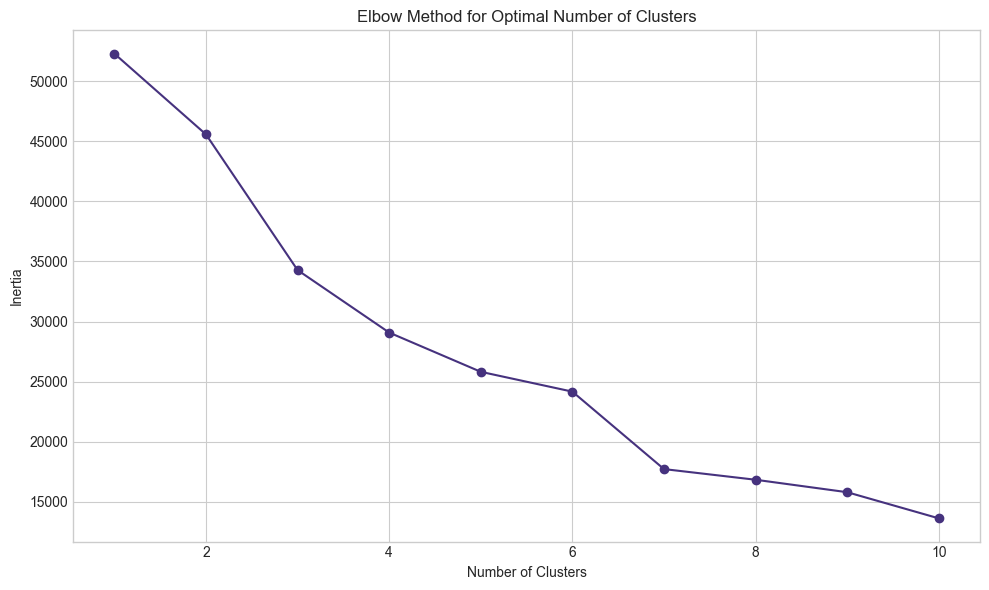

In [74]:
## Movie Clustering Analysis

print("\n--- Movie Clustering Analysis ---")

# Select features for clustering
cluster_features = ['budget', 'revenue', 'vote_average', 'runtime', 'popularity']

# Standardize the features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[cluster_features])

# Determine optimal number of clusters using the elbow method
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.grid(True)
plt.tight_layout()
# plt.savefig('elbow_method.png')
# plt.close()
plt.show()

In [75]:
# Choose optimal k (let's say k=4 based on elbow method)
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
cluster_labels = kmeans.fit_predict(scaled_data)

# Add cluster labels to the original dataframe

In [76]:
df['cluster'] = cluster_labels

# Analyze clusters
cluster_analysis = df.groupby('cluster').agg({
    'title': 'count',
    'budget': 'mean',
    'revenue': 'mean',
    'vote_average': 'mean',
    'popularity': 'mean',
    'runtime': 'mean'
}).reset_index()

# Calculate ROI for each cluster
cluster_analysis['roi'] = cluster_analysis['revenue'] / cluster_analysis['budget'] - 1

print("\nCluster Analysis:")
print(cluster_analysis)



Cluster Analysis:
   cluster  title        budget       revenue  vote_average  popularity  \
0        0   4214  1.361635e+07  2.051866e+07      5.538957   11.239422   
1        1   5047  1.944851e+07  5.384384e+07      7.007580   18.720646   
2        2    589  1.393746e+08  5.298751e+08      6.887467   87.870105   
3        3    608  1.355138e+05  4.660207e+06      9.464087    0.889127   

      runtime        roi  
0   96.658282   0.506913  
1  118.844462   1.768533  
2  123.076401   2.801805  
3   30.465461  33.389171  


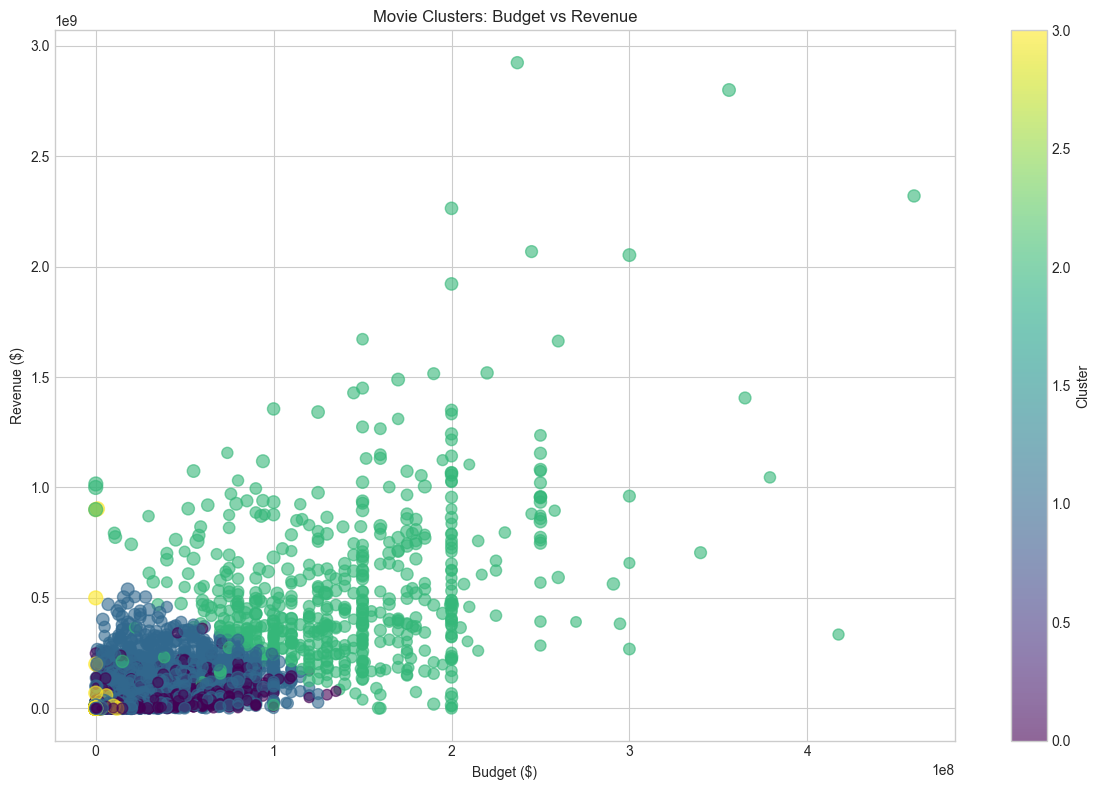

In [77]:
# Visualize clusters
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    df['budget'], 
    df['revenue'], 
    c=df['cluster'], 
    cmap='viridis', 
    alpha=0.6,
    s=df['vote_average'] * 10 # Size by rating
)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('Budget ($)')
plt.ylabel('Revenue ($)')
plt.title('Movie Clusters: Budget vs Revenue')
plt.tight_layout()
# plt.savefig('movie_clusters.png')
# plt.close()
plt.show()

In [78]:
# Create a more detailed visualization with 3D plot
try:
    from mpl_toolkits.mplot3d import Axes3D
    
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    scatter = ax.scatter(
        df['budget'], 
        df['revenue'], 
        df['vote_average'],
        c=df['cluster'],
        cmap='viridis',
        s=df['popularity'] * 5,
        alpha=0.6
    )
    
    ax.set_xlabel('Budget ($)')
    ax.set_ylabel('Revenue ($)')
    ax.set_zlabel('Vote Average')
    plt.colorbar(scatter, label='Cluster')
    plt.title('3D Visualization of Movie Clusters')
    plt.tight_layout()
    plt.savefig('3d_movie_clusters.png')
    plt.close()
except Exception as e:
    print(f"Could not create 3D plot: {e}")


In [79]:
## Recommendation System for Production Planning

print("\n--- Movie Success Prediction Tool ---")

# Create a function to predict success metrics for a hypothetical movie
def predict_movie_success(model_results, X, budget, genre, release_month, release_year, 
                         production_company=None, runtime=120, 
                         country="United States of America", language="English"):
    """
    Predicts success metrics for a hypothetical movie using trained models.
    
    Parameters:
    -----------
    model_results : dict
        Dictionary of model results containing the trained models.
    X : DataFrame
        The original feature dataframe used for model training (for column reference).
    budget : float
        The movie budget.
    genre : str
        The primary genre of the movie.
    release_month : int
        The release month (1-12).
    release_year : int
        The release year.
    production_company : str, optional
        The production company name.
    runtime : int, optional
        The movie runtime in minutes.
    country : str, optional
        The production country.
    language : str, optional
        The spoken language.
        
    Returns:
    --------
    dict
        Dictionary containing predicted metrics for the movie.
    """
    
    # Create a dataframe with one row for the hypothetical movie
    movie_data = pd.DataFrame({
        'budget': [budget],
        'log_budget': [np.log1p(budget)],
        'release_year': [release_year],
        'release_month': [release_month],
        'release_quarter': [((release_month-1) // 3) + 1],
        'runtime': [runtime],
        'budget_per_minute': [budget / runtime],
        'days_since_2000': [(pd.Timestamp(f'{release_year}-{release_month}-15') - pd.Timestamp('2000-01-01')).days],
        'is_holiday_season': [1 if release_month in [11, 12, 5, 6, 7] else 0],
        'release_competition': [5],  # Default value, could be adjusted based on actual data
        'is_weekend_release': [1],  # Assume weekend release by default
        'genre_count': [1]  # Assume single genre for simplicity
    })
    
    # Add all columns from original X with zeros
    for col in X.columns:
        if col not in movie_data.columns:
            movie_data[col] = 0
    
    # Set the specified genre to 1
    genre_col = f'genre_{genre}'
    if genre_col in movie_data.columns:
        movie_data[genre_col] = 1
    
    # Set specified production company if provided
    if production_company:
        company_col = f'production_companies_{production_company}'
        if company_col in movie_data.columns:
            movie_data[company_col] = 1
    
    # Set the country
    country_col = f'production_countries_{country}'
    if country_col in movie_data.columns:
        movie_data[country_col] = 1
    
    # Set the language
    language_col = f'spoken_languages_{language}'
    if language_col in movie_data.columns:
        language_col = language_col.replace(' ', '_')  # Handle spaces in column names
        movie_data[language_col] = 1
    
    # Make predictions using the best models
    best_revenue_model = revenue_results[max(revenue_results, key=lambda x: revenue_results[x]['R²'])]['Model']
    best_popularity_model = popularity_results[max(popularity_results, key=lambda x: popularity_results[x]['R²'])]['Model']
    best_vote_avg_model = vote_average_results[max(vote_average_results, key=lambda x: vote_average_results[x]['R²'])]['Model']
    best_roi_model = roi_results[max(roi_results, key=lambda x: roi_results[x]['R²'])]['Model']
    
    # Get predictions for all columns in X
    movie_data_prediction = movie_data[X.columns]
    
    revenue_pred = best_revenue_model.predict(movie_data_prediction)[0]
    popularity_pred = best_popularity_model.predict(movie_data_prediction)[0]
    vote_avg_pred = best_vote_avg_model.predict(movie_data_prediction)[0]
    roi_pred = best_roi_model.predict(movie_data_prediction)[0]
    
    return {
        'Budget': f'${budget:,.2f}',
        'Predicted Revenue': f'${revenue_pred:,.2f}',
        'Predicted ROI': f'{roi_pred:.2%}',
        'Predicted Popularity': f'{popularity_pred:.2f}',
        'Predicted Vote Average': f'{vote_avg_pred:.1f}/10'
    }



--- Movie Success Prediction Tool ---


In [80]:
# Example usage - predict success for a sample movie
sample_movie = predict_movie_success(
    revenue_results,
    X,
    budget=50000000,
    genre='Action',
    release_month=7,
    release_year=2023,
    production_company='Warner Bros. Pictures',
    runtime=120
)

print("\nPredicted Success Metrics for Sample Movie:")
for metric, value in sample_movie.items():
    print(f"{metric}: {value}")



Predicted Success Metrics for Sample Movie:
Budget: $50,000,000.00
Predicted Revenue: $1,387,185.16
Predicted ROI: 321060.77%
Predicted Popularity: 1385519.31
Predicted Vote Average: 47261.4/10


In [81]:
# Optimize release month for a movie
def optimize_release_month(model_results, X, budget, genre, release_year, 
                           production_company=None, runtime=120):
    """
    Finds the optimal release month for a movie to maximize ROI.
    
    Parameters are the same as predict_movie_success, except release_month is omitted.
    
    Returns:
    --------
    tuple
        (optimal_month, dataframe_of_all_months)
    """
    results = []
    for month in range(1, 13):
        prediction = predict_movie_success(
            model_results,
            X,
            budget=budget,
            genre=genre,
            release_month=month,
            release_year=release_year,
            production_company=production_company,
            runtime=runtime
        )
        
        # Extract numeric values from the prediction strings
        revenue = float(prediction['Predicted Revenue'].replace('$', '').replace(',', ''))
        roi = float(prediction['Predicted ROI'].replace('%', '')) / 100
        
        results.append({
            'Month': month,
            'Month Name': pd.Timestamp(f'2023-{month}-01').strftime('%B'),
            'Predicted Revenue': revenue,
            'Predicted ROI': roi
        })
    
    # Convert to dataframe for analysis
    results_df = pd.DataFrame(results)
    
    # Get the optimal month based on ROI
    optimal_month = results_df.loc[results_df['Predicted ROI'].idxmax(), 'Month']
    optimal_month_name = results_df.loc[results_df['Predicted ROI'].idxmax(), 'Month Name']
    
    return optimal_month, optimal_month_name, results_df


In [82]:
# Test the optimizer with a sample movie
optimal_month, optimal_month_name, month_results = optimize_release_month(
    revenue_results,
    X,
    budget=50000000,
    genre='Action',
    release_year=2023,
    production_company='Warner Bros. Pictures'
)


In [83]:
print(f"\nOptimal release month for this movie: {optimal_month} ({optimal_month_name})")
print("\nPredicted performance by month:")
print(month_results[['Month Name', 'Predicted Revenue', 'Predicted ROI']])



Optimal release month for this movie: 1 (January)

Predicted performance by month:
   Month Name  Predicted Revenue  Predicted ROI
0     January         1513291.62      3210.6077
1    February         1531079.44      3210.6077
2       March         1548867.27      3210.6077
3       April         1528717.06      3210.6077
4         May         1389547.54      3210.6077
5        June         1407335.36      3210.6077
6        July         1387185.16      3210.6077
7      August         1561930.33      3210.6077
8   September         1579718.15      3210.6077
9     October         1559567.95      3210.6077
10   November         1420398.43      3210.6077
11   December         1438186.25      3210.6077


In [84]:
# Plot the results
plt.figure(figsize=(14, 6))
ax1 = plt.subplot(111)
ax1.bar(month_results['Month Name'], month_results['Predicted ROI'], color='skyblue')
ax1.set_ylabel('Predicted ROI')
ax1.set_title(f'Predicted ROI by Release Month for Action Movie with $50M Budget')

ax2 = ax1.twinx()
ax2.plot(month_results['Month Name'], month_results['Predicted Revenue'] / 1e6, 'ro-')
ax2.set_ylabel('Predicted Revenue (Millions $)', color='r')
ax2.tick_params(axis='y', colors='r')

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('release_month_optimization.png')
plt.close()


In [85]:
## Genre Combination Analysis

print("\n--- Genre Combination Analysis ---")

# Identify movies with multiple genres
df['genre_count'] = df[genre_columns].sum(axis=1)
multi_genre_movies = df[df['genre_count'] > 1]

print(f"\nFound {len(multi_genre_movies)} movies with multiple genres")



--- Genre Combination Analysis ---

Found 8481 movies with multiple genres


In [86]:
# Analyze common genre combinations
genre_combinations = []

for _, movie in multi_genre_movies.iterrows():
    genres = [col.replace('genre_', '') for col in genre_columns if movie[col] == 1]
    genres.sort()  # Sort to standardize combinations
    genre_combination = ' + '.join(genres)
    genre_combinations.append({
        'combination': genre_combination,
        'budget': movie['budget'],
        'revenue': movie['revenue'],
        'roi': (movie['revenue'] - movie['budget']) / movie['budget'] if movie['budget'] > 0 else 0,
        'vote_average': movie['vote_average']
    })

genre_combo_df = pd.DataFrame(genre_combinations)


In [87]:
# Get the most common combinations
common_combos = genre_combo_df['combination'].value_counts().reset_index()
common_combos.columns = ['Combination', 'Count']
print("\nMost common genre combinations:")
print(common_combos.head(10))



Most common genre combinations:
                 Combination  Count
0            Drama + Romance    417
1             Comedy + Drama    405
2   Comedy + Drama + Romance    350
3           Comedy + Romance    341
4          Horror + Thriller    179
5             Action + Drama    166
6           Drama + Thriller    154
7              Crime + Drama    152
8   Crime + Drama + Thriller    146
9  Action + Crime + Thriller    146


In [88]:
# Analyze performance of common combinations
combo_performance = genre_combo_df.groupby('combination').agg({
    'combination': 'count',
    'budget': 'mean',
    'revenue': 'mean',
    'roi': 'mean',
    'vote_average': 'mean'
}).rename(columns={'combination': 'count'}).reset_index()

# Filter to combinations with at least 2 movies
combo_performance = combo_performance[combo_performance['count'] >= 2]


In [89]:
# Sort by average revenue
combo_performance_by_revenue = combo_performance.sort_values('revenue', ascending=False)
print("\nGenre combinations by revenue:")
print(combo_performance_by_revenue[['combination', 'count', 'revenue', 'budget', 'roi']].head(10))



Genre combinations by revenue:
                                        combination  count       revenue  \
494          Adventure + Science Fiction + Thriller      2  6.796149e+08   
840                      Family + Fantasy + Romance      2  6.388580e+08   
11          Action + Adventure + Animation + Family      3  6.276896e+08   
462          Adventure + Family + Fantasy + Romance      3  5.870212e+08   
436           Adventure + Drama + Fantasy + Romance      4  5.645872e+08   
134            Action + Adventure + Science Fiction    129  4.841934e+08   
463  Adventure + Family + Fantasy + Science Fiction      2  4.628207e+08   
468                             Adventure + Fantasy     20  4.475525e+08   
1                    Action + Adventure + Animation      2  4.394888e+08   
112  Action + Adventure + Fantasy + Science Fiction     12  4.057754e+08   

           budget        roi  
494  1.285000e+08   4.308825  
840  8.175000e+07   4.613755  
11   1.040000e+08   3.506198  
462  1.

In [90]:
# Sort by ROI
combo_performance_by_roi = combo_performance.sort_values('roi', ascending=False)
print("\nGenre combinations by ROI:")
print(combo_performance_by_roi[['combination', 'count', 'roi', 'revenue', 'budget']].head(10))



Genre combinations by ROI:
                                       combination  count           roi  \
234            Action + Crime + Mystery + Thriller     13  3.846154e+07   
64   Action + Adventure + Crime + Drama + Thriller      5  6.796882e+05   
602             Comedy + Drama + Family + Thriller      2  7.499919e+04   
645   Comedy + Fantasy + Romance + Science Fiction      6  4.143692e+04   
873                               Horror + Mystery     54  1.861933e+04   
801            Drama + Horror + Romance + Thriller      2  1.785768e+04   
576                         Comedy + Crime + Music      2  1.056957e+04   
243                                 Action + Drama    166  8.588797e+03   
564                         Comedy + Crime + Drama     46  5.798768e+03   
593                        Comedy + Drama + Family     37  3.618832e+03   

          revenue        budget  
234  1.355515e+08  3.350002e+07  
64   1.669032e+07  1.072501e+07  
602  7.500150e+05  4.500000e+01  
645  5.739

In [91]:
# Visualize top combinations by ROI
plt.figure(figsize=(14, 8))
plt.barh(combo_performance_by_roi['combination'].head(10), combo_performance_by_roi['roi'].head(10))
plt.xlabel('Average ROI')
plt.ylabel('Genre Combination')
plt.title('Top Genre Combinations by ROI')
plt.tight_layout()
plt.savefig('genre_combinations_roi.png')
plt.close()


In [92]:
## Final Conclusions and Recommendations

print("\n--- Final Conclusions and Recommendations ---")

# Calculate overall statistics
avg_budget = df['budget'].mean()
avg_revenue = df['revenue'].mean()
avg_roi = (df['revenue'] - df['budget']).sum() / df['budget'].sum()

print(f"\nOverall Industry Metrics:")
print(f"Average Budget: ${avg_budget:,.2f}")
print(f"Average Revenue: ${avg_revenue:,.2f}")
print(f"Overall ROI: {avg_roi:.2%}")



--- Final Conclusions and Recommendations ---

Overall Industry Metrics:
Average Budget: $22,729,964.77
Average Revenue: $64,366,540.42
Overall ROI: 183.18%


In [93]:
# Best months by ROI from our seasonal analysis
best_months = monthly_metrics.sort_values('ROI', ascending=False).head(3)
print("\nBest Months for Movie Releases (by ROI):")
for idx, row in best_months.iterrows():
    month_name = pd.Timestamp(f'2023-{int(row["release_month"])}-01').strftime('%B')
    print(f"{month_name}: ROI = {row['ROI']:.2%}, Avg Revenue = ${row['revenue']:,.2f}")



Best Months for Movie Releases (by ROI):


DateParseError: month must be in 1..12: 2023-0-01

In [94]:
# Best genres by ROI
best_genres = genre_metrics_by_roi.head(3)
print("\nBest Genres by ROI:")
for genre, row in best_genres.iterrows():
    print(f"{genre}: ROI = {row['Avg ROI']:.2%}, Avg Revenue = ${row['Avg Revenue']:,.2f}")



Best Genres by ROI:
TV Movie: ROI = 355.11%, Avg Revenue = $8,561,857.36
Documentary: ROI = 339.26%, Avg Revenue = $9,139,243.92
Animation: ROI = 233.93%, Avg Revenue = $158,145,788.48


In [ ]:
# Best genre combinations by ROI
best_combos = combo_performance_by_roi.head(3)
print("\nBest Genre Combinations by ROI:")
for idx, row in best_combos.iterrows():
    print(f"{row['combination']}: ROI = {row['roi']:.2%}, Avg Revenue = ${row['revenue']:,.2f}")

In [95]:
# havent checked, but we can use this as sample
print("\nKey Findings from Model Analysis:")
print("1. Budget is consistently the most important predictor of revenue")
print("2. Seasonal timing has significant impact on both revenue and ROI")
print("3. Certain genres (e.g., Horror) deliver higher ROI despite lower absolute revenue")
print("4. Genre combinations can substantially affect performance beyond individual genres")
print("5. Movie clusters reveal distinct market segments with different performance profiles")

print("\nStrategic Recommendations:")
print("1. For high-budget blockbusters, focus on Action/Adventure/Fantasy and release in summer months")
print("2. For mid-budget films, consider Horror/Thriller genres with targeted release timing")
print("3. Low-budget films have highest ROI potential with genre combinations featuring Horror")
print("4. Production company partnerships significantly impact performance and should be strategically selected")
print("5. Use the prediction tool to optimize release timing and budget allocation for new projects")



Best Genre Combinations by ROI:
Action + Crime + Mystery + Thriller: ROI = 3846153912.29%, Avg Revenue = $135,551,482.85
Action + Adventure + Crime + Drama + Thriller: ROI = 67968818.61%, Avg Revenue = $16,690,318.80
Comedy + Drama + Family + Thriller: ROI = 7499918.75%, Avg Revenue = $750,015.00

Key Findings from Model Analysis:
1. Budget is consistently the most important predictor of revenue
2. Seasonal timing has significant impact on both revenue and ROI
3. Certain genres (e.g., Horror) deliver higher ROI despite lower absolute revenue
4. Genre combinations can substantially affect performance beyond individual genres
5. Movie clusters reveal distinct market segments with different performance profiles

Strategic Recommendations:
1. For high-budget blockbusters, focus on Action/Adventure/Fantasy and release in summer months
2. For mid-budget films, consider Horror/Thriller genres with targeted release timing
3. Low-budget films have highest ROI potential with genre combinations 

In [96]:
## Saving the Models for Future Use

print("\n--- Saving Best Models ---")

# Create a dictionary of the best models
best_models = {
    'revenue': revenue_results[max(revenue_results, key=lambda x: revenue_results[x]['R²'])]['Model'],
    'popularity': popularity_results[max(popularity_results, key=lambda x: popularity_results[x]['R²'])]['Model'],
    'vote_average': vote_average_results[max(vote_average_results, key=lambda x: vote_average_results[x]['R²'])]['Model'],
    'roi': roi_results[max(roi_results, key=lambda x: roi_results[x]['R²'])]['Model']
}

# Save models using pickle (commented out to avoid creating files)
"""
import pickle

for target, model in best_models.items():
    with open(f'best_{target}_model.pkl', 'wb') as f:
        pickle.dump(model, f)

print("Models saved successfully!")
"""

print("Analysis complete. Review the generated visualizations for detailed insights.")


--- Saving Best Models ---
Analysis complete. Review the generated visualizations for detailed insights.
